In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [5]:
metrics

{'loss': np.float32(-64835.062),
 'loss_batch_mean': np.float32(-506.52393),
 'log_w': np.float32(56730.67),
 'log_w_batch_mean': np.float32(443.20837)}

In [6]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


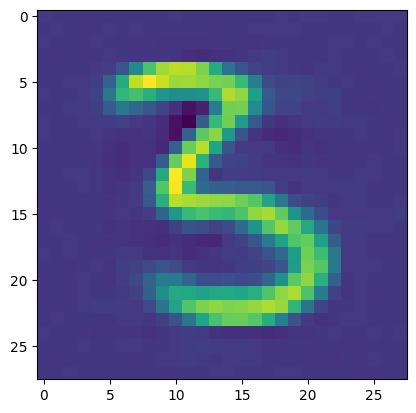

In [7]:
plt.imshow(recons[0].squeeze())

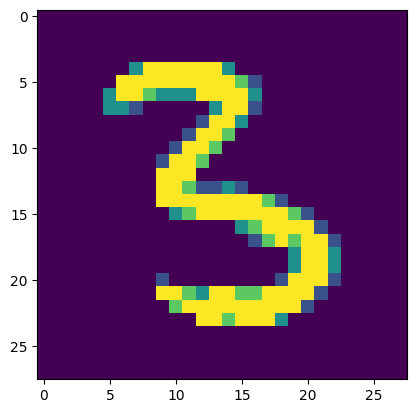

In [8]:
plt.imshow(data[0].squeeze())

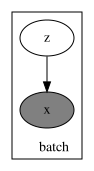

In [9]:
objects['monad'].render_model()

In [10]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [11]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_

In [12]:
portion_zeros(zs)

Array(0.9196285, dtype=float32)

In [13]:
r2(xs, xs_hat)

Array(0.901718, dtype=float32)

In [14]:
xs.shape

(9984, 1, 28, 28)

In [15]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=omniglot", "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [16]:
metrics

{'loss': np.float32(-27976.525),
 'loss_batch_mean': np.float32(-218.5666),
 'log_w': np.float32(24479.455),
 'log_w_batch_mean': np.float32(191.24574)}

In [17]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


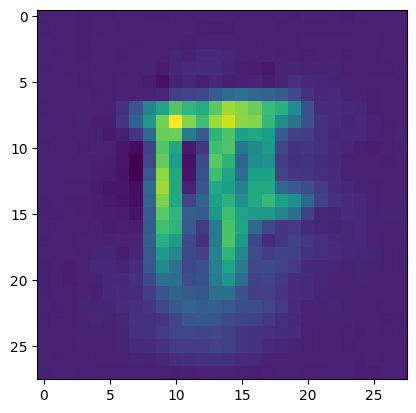

In [18]:
plt.imshow(recons[0].squeeze())

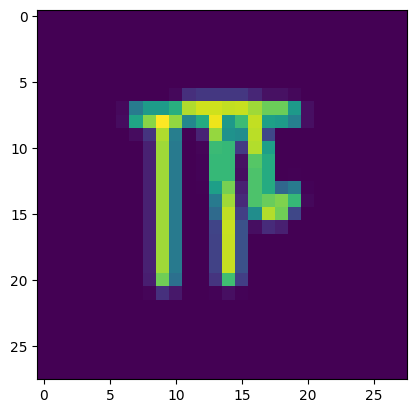

In [19]:
plt.imshow(data[0].squeeze())

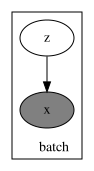

In [20]:
objects['monad'].render_model()

In [21]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [22]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)
/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:79: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_

In [23]:
portion_zeros(zs)

Array(0.9302221, dtype=float32)

In [24]:
r2(xs, xs_hat)

Array(0.62358296, dtype=float32)

In [25]:
xs.shape

(13056, 1, 28, 28)